# 05. Q_FIXED 민감도 분석 — GARCH + Baseline 비교

## 목적
Q_FIXED 값에 따른 BL 포트폴리오 성과 변화를 **GARCH vol**과 **Baseline vol(vol_21d)** 두 가지 소스에서 분석하여 각각의 최적 Q를 도출한다.

## 설계
- Vol 소스: GARCH(04번 출력) + Baseline(vol_21d 현재값) 각각 독립 실행
- Q 후보: `[0.001, 0.002, 0.003, 0.005, 0.007, 0.010, 0.015, 0.020]`
- 기간: 2011-01 ~ 2025-12
- 지표: 연환산수익률, 연환산변동성, Sharpe, MDD, 누적수익률
- 출력: `q_sensitivity_stats.csv` (GARCH → 08 로드), `q_sensitivity_baseline_stats.csv` (Baseline → 06 로드)

## 파라미터 표

| 파라미터 | 값 | 설명 |
|---------|-----|------|
| `TRAIN_WINDOW` | 60 | 학습 윈도우 (월) |
| `TAU` | 0.1 | BL 불확실성 스케일 |
| `PCT_GROUP` | 0.30 | 저위험/고위험 분류 비율 |
| `Q_CANDIDATES` | [0.001~0.020] | 탐색 Q 값 목록 |
| `START_PRED` | 2011-01-01 | GARCH 가용 시작일 |

## 실행 의존성
```
04_VolatilityPrediction → vol_predicted.csv
        ↓
05_Q_Sensitivity → q_sensitivity_stats.csv          (GARCH → 08_Regime_Q_Portfolio)
                 → q_sensitivity_baseline_stats.csv (Baseline → 06_BL_Q_Comparison)
```

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
import platform
from pathlib import Path
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
OUT_DIR  = BASE_DIR / 'outputs' / '05_Q_Sensitivity'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 파라미터 ────────────────────────────────────────────────
TRAIN_WINDOW  = 60
TAU           = 0.1
PCT_GROUP     = 0.30
START_PRED    = '2011-01-01'
Q_CANDIDATES  = [0.001, 0.002, 0.003, 0.005, 0.007, 0.010, 0.015, 0.020]

# ── 데이터 로드 ──────────────────────────────────────────────
panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', parse_dates=['date'])
panel = panel.set_index(['date', 'ticker'])

all_dates  = panel.index.get_level_values('date').unique().sort_values()
pred_dates = all_dates[all_dates >= START_PRED]

ret_pivot  = panel['ret_1m'].unstack('ticker')
vol_pivot  = panel['vol_21d'].unstack('ticker')
spy_series = panel['spy_ret'].groupby(level='date').first()
rf_series  = panel['rf_1m'].groupby(level='date').first()

# ── GARCH 예측 vol 로드 ──────────────────────────────────────
PRED_PATH = DATA_DIR / 'vol_predicted.csv'
assert PRED_PATH.exists(), '04_VolatilityPrediction.ipynb 먼저 실행해 vol_predicted.csv 생성하세요'
vol_pred_df    = pd.read_csv(PRED_PATH, parse_dates=['date'])
vol_pred_pivot = vol_pred_df.set_index(['date', 'ticker'])['vol_pred'].unstack('ticker')

print(f'패널: {panel.shape}')
print(f'예측 기간: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')
print(f'GARCH vol 로드: {vol_pred_pivot.shape}')
print(f'Q 탐색 범위: {Q_CANDIDATES}')

패널: (108135, 11)
예측 기간: 2011-01-31 ~ 2025-12-31 (180개월)
GARCH vol 로드: (180, 610)
Q 탐색 범위: [0.001, 0.002, 0.003, 0.005, 0.007, 0.01, 0.015, 0.02]


# BL 구성 함수

In [9]:
def compute_sigma(ret_matrix):
    lw = LedoitWolf().fit(ret_matrix.values)
    return pd.DataFrame(lw.covariance_,
                        index=ret_matrix.columns,
                        columns=ret_matrix.columns)


def compute_pi(Sigma, w_mkt, spy_excess_ret, sigma2_mkt):
    lam = spy_excess_ret / sigma2_mkt if sigma2_mkt > 0 else 2.5
    lam = np.clip(lam, 0.5, 10.0)
    return lam * Sigma @ w_mkt, lam


def build_P(vol_series, mcap_series, pct=0.30):
    n_group    = max(1, int(len(vol_series) * pct))
    sorted_idx = vol_series.sort_values().index
    low_risk   = sorted_idx[:n_group]
    high_risk  = sorted_idx[-n_group:]
    P = pd.Series(0.0, index=vol_series.index)
    low_m  = mcap_series[low_risk]
    high_m = mcap_series[high_risk]
    P[low_risk]  =  low_m  / low_m.sum()
    P[high_risk] = -high_m / high_m.sum()
    return P


def compute_omega(P, Sigma, tau):
    p = P.values
    return max(float(tau * p @ Sigma.values @ p), 1e-8)


def black_litterman(pi, Sigma, P, q, omega, tau):
    """BL posterior mean: μ_BL = π + τΣP^T(PτΣP^T + Ω)^{-1}(Q - Pπ)"""
    p    = P.values
    pi_v = pi.values
    tSig = tau * Sigma.values
    M      = float(p @ tSig @ p) + omega
    diff   = q - float(p @ pi_v)      # Q - Pπ: BL 조정의 방향과 크기
    adjust = tSig @ p * (diff / M)
    return pd.Series(pi_v + adjust, index=pi.index)


def optimize_portfolio(mu, Sigma, lam):
    n   = len(mu)
    mu_ = mu.values
    Sig = Sigma.values
    def obj(w): return 0.5 * lam * w @ Sig @ w - w @ mu_
    def jac(w): return lam * Sig @ w - mu_
    res = minimize(obj, np.ones(n)/n, jac=jac, method='SLSQP',
                   bounds=[(0, 1)]*n,
                   constraints=[{'type': 'eq', 'fun': lambda w: w.sum()-1}])
    if not res.success:
        import warnings
        warnings.warn(f'optimize_portfolio 수렴 실패 → 1/N 대체: {res.message}')
    w = res.x if res.success else np.ones(n)/n
    return pd.Series(w, index=mu.index)


print('BL 함수 정의 완료')


BL 함수 정의 완료


# Walk-forward: GARCH + Q 민감도

매 pred_date마다:
1. GARCH vol로 P 행렬 구성
2. Sigma, π 계산 (1회)
3. Q_CANDIDATES 각 값으로 BL → MVO → 수익률 기록
4. CAPM, SPY 벤치마크 (1회)

In [10]:
results = {f'Q={q:.3f}': [] for q in Q_CANDIDATES}
results['CAPM'] = []
results['SPY']  = []

print(f'Walk-forward: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')
print(f'Q 후보 {len(Q_CANDIDATES)}개: {Q_CANDIDATES}')
print(f'[GARCH vol 고정]')

for i, pred_date in enumerate(pred_dates):
    if (i + 1) % 12 == 0:
        print(f'  {pred_date.date()} ({i+1}/{len(pred_dates)})')

    try:
        # ── 공통 데이터 준비 ─────────────────────────────────
        month_base = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_base) < 30:
            continue

        idx         = all_dates.get_loc(pred_date)
        train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]
        rf_s        = rf_series.reindex(train_dates)
        spy_s       = spy_series.reindex(train_dates)
        spy_excess  = (spy_s - rf_s).mean()
        sigma2_mkt  = spy_s.var()

        next_date = all_dates[idx + 1] if idx + 1 < len(all_dates) else None
        r_spy     = float(spy_series.get(next_date, np.nan)) if next_date else np.nan

        # ── GARCH vol 적용 ───────────────────────────────────
        if pred_date not in vol_pred_pivot.index:
            continue
        month_df = month_base.copy()
        pred_vol = vol_pred_pivot.loc[pred_date].reindex(month_df.index)
        month_df['vol_use'] = pred_vol
        month_df = month_df.dropna(subset=['vol_use'])
        if len(month_df) < 20:
            continue

        # ── 유니버스 필터링 ──────────────────────────────────
        universe  = month_df.index.tolist()
        thresh    = int(len(train_dates) * 0.7)
        ret_slice = (ret_pivot.reindex(index=train_dates, columns=universe)
                              .dropna(axis=1, thresh=thresh)
                              .fillna(0))
        valid_tix = ret_slice.columns.tolist()
        if len(valid_tix) < 20:
            continue

        month_df   = month_df.reindex(valid_tix)
        Sigma      = compute_sigma(ret_slice)
        mcap       = np.exp(month_df['log_mcap'])
        w_mkt      = (mcap / mcap.sum()).reindex(valid_tix).fillna(0)
        pi, lam    = compute_pi(Sigma, w_mkt, spy_excess, sigma2_mkt)
        P          = build_P(month_df['vol_use'], mcap, pct=PCT_GROUP)
        P          = P.reindex(valid_tix).fillna(0)
        omega      = compute_omega(P, Sigma, TAU)
        actual_ret = (ret_pivot.loc[next_date].reindex(valid_tix).fillna(0)
                            if next_date is not None
                            else month_df['fwd_ret_1m'].reindex(valid_tix).fillna(0))

        # ── Q 후보별 BL 실행 ─────────────────────────────────
        for q_val in Q_CANDIDATES:
            key   = f'Q={q_val:.3f}'
            mu_BL = black_litterman(pi, Sigma, P, q_val, omega, TAU)
            w_bl  = optimize_portfolio(mu_BL, Sigma, lam)
            results[key].append({'date': pred_date, 'ret': float(w_bl @ actual_ret)})

        # ── CAPM / SPY 벤치마크 ──────────────────────────────
        w_capm = optimize_portfolio(pi, Sigma, lam)
        results['CAPM'].append({'date': pred_date, 'ret': float(w_capm @ actual_ret)})
        results['SPY'].append({'date': pred_date, 'ret': r_spy})

    except Exception as e:
        if i < 5:
            print(f'  [에러] {pred_date.date()}: {e}')

ret_series = {k: pd.DataFrame(v).set_index('date')['ret']
              for k, v in results.items() if v}

print(f'\n완료')
for k, s in ret_series.items():
    print(f'  {k}: {len(s)}개월')


Walk-forward: 2011-01-31 ~ 2025-12-31 (180개월)
Q 후보 8개: [0.001, 0.002, 0.003, 0.005, 0.007, 0.01, 0.015, 0.02]
[GARCH vol 고정]
  2011-12-31 (12/180)
  2012-12-31 (24/180)
  2013-12-31 (36/180)
  2014-12-31 (48/180)
  2015-12-31 (60/180)
  2016-12-31 (72/180)
  2017-12-31 (84/180)
  2018-12-31 (96/180)
  2019-12-31 (108/180)
  2020-12-31 (120/180)
  2021-12-31 (132/180)
  2022-12-31 (144/180)
  2023-12-31 (156/180)
  2024-12-31 (168/180)
  2025-12-31 (180/180)

완료
  Q=0.001: 180개월
  Q=0.002: 180개월
  Q=0.003: 180개월
  Q=0.005: 180개월
  Q=0.007: 180개월
  Q=0.010: 180개월
  Q=0.015: 180개월
  Q=0.020: 180개월
  CAPM: 180개월
  SPY: 180개월


# Walk-forward: Baseline (vol_21d) + Q 민감도

매 pred_date마다:
1. **vol_21d** (현재 실현변동성)로 P 행렬 구성
2. Sigma, π 계산 (1회)
3. Q_CANDIDATES 각 값으로 BL → MVO → 수익률 기록
4. CAPM·SPY 벤치마크는 GARCH 루프에서 이미 수집됨

In [11]:
baseline_results = {f'Baseline_Q={q:.3f}': [] for q in Q_CANDIDATES}

print(f'Walk-forward (Baseline vol_21d): {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')
print(f'Q 후보 {len(Q_CANDIDATES)}개: {Q_CANDIDATES}')
print(f'[Baseline vol_21d 고정]')

for i, pred_date in enumerate(pred_dates):
    if (i + 1) % 12 == 0:
        print(f'  {pred_date.date()} ({i+1}/{len(pred_dates)})')

    try:
        # ── 공통 데이터 준비 ─────────────────────────────────
        month_df = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_df) < 30:
            continue

        idx         = all_dates.get_loc(pred_date)
        train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]
        rf_s        = rf_series.reindex(train_dates)
        spy_s       = spy_series.reindex(train_dates)
        spy_excess  = (spy_s - rf_s).mean()
        sigma2_mkt  = spy_s.var()

        universe  = month_df.index.tolist()
        thresh    = int(len(train_dates) * 0.7)
        ret_slice = (ret_pivot.reindex(index=train_dates, columns=universe)
                              .dropna(axis=1, thresh=thresh)
                              .fillna(0))
        valid_tix = ret_slice.columns.tolist()
        if len(valid_tix) < 20:
            continue

        month_df   = month_df.reindex(valid_tix)
        Sigma      = compute_sigma(ret_slice)
        mcap       = np.exp(month_df['log_mcap'])
        w_mkt      = (mcap / mcap.sum()).reindex(valid_tix).fillna(0)
        pi, lam    = compute_pi(Sigma, w_mkt, spy_excess, sigma2_mkt)

        # ── Baseline vol_21d 사용 ────────────────────────────
        P     = build_P(month_df['vol_21d'], mcap, pct=PCT_GROUP)
        P     = P.reindex(valid_tix).fillna(0)
        omega = compute_omega(P, Sigma, TAU)
        next_date  = all_dates[idx + 1] if idx + 1 < len(all_dates) else None
        actual_ret = (ret_pivot.loc[next_date].reindex(valid_tix).fillna(0)
                            if next_date is not None
                            else month_df['fwd_ret_1m'].reindex(valid_tix).fillna(0))

        for q_val in Q_CANDIDATES:
            key   = f'Baseline_Q={q_val:.3f}'
            mu_BL = black_litterman(pi, Sigma, P, q_val, omega, TAU)
            w_bl  = optimize_portfolio(mu_BL, Sigma, lam)
            baseline_results[key].append({'date': pred_date, 'ret': float(w_bl @ actual_ret)})

    except Exception as e:
        if i < 5:
            print(f'  [에러] {pred_date.date()}: {e}')

baseline_ret_series = {k: pd.DataFrame(v).set_index('date')['ret']
                       for k, v in baseline_results.items() if v}

print(f'\n완료')
for k, s in baseline_ret_series.items():
    print(f'  {k}: {len(s)}개월')


Walk-forward (Baseline vol_21d): 2011-01-31 ~ 2025-12-31 (180개월)
Q 후보 8개: [0.001, 0.002, 0.003, 0.005, 0.007, 0.01, 0.015, 0.02]
[Baseline vol_21d 고정]
  2011-12-31 (12/180)
  2012-12-31 (24/180)
  2013-12-31 (36/180)
  2014-12-31 (48/180)
  2015-12-31 (60/180)
  2016-12-31 (72/180)
  2017-12-31 (84/180)
  2018-12-31 (96/180)
  2019-12-31 (108/180)
  2020-12-31 (120/180)
  2021-12-31 (132/180)
  2022-12-31 (144/180)
  2023-12-31 (156/180)
  2024-12-31 (168/180)
  2025-12-31 (180/180)

완료
  Baseline_Q=0.001: 180개월
  Baseline_Q=0.002: 180개월
  Baseline_Q=0.003: 180개월
  Baseline_Q=0.005: 180개월
  Baseline_Q=0.007: 180개월
  Baseline_Q=0.010: 180개월
  Baseline_Q=0.015: 180개월
  Baseline_Q=0.020: 180개월


# 성과 분석 및 최적 Q 탐색

In [12]:
ANN        = np.sqrt(12)
rf_monthly = panel['rf_1m'].groupby(level='date').first()

def performance(ret, label):
    rf     = rf_monthly.reindex(ret.index).fillna(0)
    excess = ret - rf
    ann_ret = ret.mean() * 12
    ann_vol = ret.std() * ANN
    sharpe  = excess.mean() / excess.std() * ANN
    cum     = (1 + ret).cumprod()
    mdd     = ((cum - cum.cummax()) / cum.cummax()).min()
    cum_ret = cum.iloc[-1] - 1
    return {'label': label, 'ann_ret': ann_ret, 'ann_vol': ann_vol,
            'sharpe': sharpe, 'cum_ret': cum_ret, 'mdd': mdd}

# ── GARCH 성과 ─────────────────────────────────────────────────
GARCH_ORDER = [f'Q={q:.3f}' for q in Q_CANDIDATES] + ['CAPM', 'SPY']
garch_stats = [performance(ret_series[k], k) for k in GARCH_ORDER if k in ret_series]
garch_df    = pd.DataFrame(garch_stats).set_index('label')

garch_bl         = garch_df.drop(index=['CAPM', 'SPY'], errors='ignore')
Q_OPTIMAL_GARCH  = float(garch_bl['sharpe'].idxmax().split('=')[1])
SHARPE_GARCH_OPT = garch_bl['sharpe'].max()

print('=' * 65)
print('GARCH + Q_FIXED 민감도 분석 (2011-01 ~ 2025-12)')
print('=' * 65)
disp = garch_df.copy()
for col, fmt in [('ann_ret', '{:.2%}'), ('ann_vol', '{:.2%}'),
                 ('sharpe',  '{:.3f}'), ('cum_ret', '{:.2%}'), ('mdd', '{:.2%}')]:
    disp[col] = disp[col].map(fmt.format)
disp.columns = ['연환산수익률', '연환산변동성', 'Sharpe', '누적수익률', 'MDD']
print(disp.to_string())
print(f'\n★ GARCH 최적 Q: Q={Q_OPTIMAL_GARCH:.3f}  →  Sharpe {SHARPE_GARCH_OPT:.3f}')

# ── Baseline 성과 ──────────────────────────────────────────────
BL_ORDER = [f'Baseline_Q={q:.3f}' for q in Q_CANDIDATES]
bl_stats = [performance(baseline_ret_series[k], k)
            for k in BL_ORDER if k in baseline_ret_series]
bl_df    = pd.DataFrame(bl_stats).set_index('label')

Q_OPTIMAL_BASELINE  = float(bl_df['sharpe'].idxmax().split('=')[1])
SHARPE_BASELINE_OPT = bl_df['sharpe'].max()

print()
print('=' * 65)
print('Baseline (vol_21d) + Q_FIXED 민감도 분석 (2011-01 ~ 2025-12)')
print('=' * 65)
disp2 = bl_df.copy()
for col, fmt in [('ann_ret', '{:.2%}'), ('ann_vol', '{:.2%}'),
                 ('sharpe',  '{:.3f}'), ('cum_ret', '{:.2%}'), ('mdd', '{:.2%}')]:
    disp2[col] = disp2[col].map(fmt.format)
disp2.columns = ['연환산수익률', '연환산변동성', 'Sharpe', '누적수익률', 'MDD']
print(disp2.to_string())
print(f'\n★ Baseline 최적 Q: Baseline_Q={Q_OPTIMAL_BASELINE:.3f}  →  Sharpe {SHARPE_BASELINE_OPT:.3f}')

print()
print('[ 최적 Q 비교 ]')
print(f'  GARCH    최적 Q = {Q_OPTIMAL_GARCH:.3f}   Sharpe {SHARPE_GARCH_OPT:.3f}')
print(f'  Baseline 최적 Q = {Q_OPTIMAL_BASELINE:.3f}   Sharpe {SHARPE_BASELINE_OPT:.3f}')

# ── 저장 ──────────────────────────────────────────────────────
# 08_Regime_Q_Portfolio.ipynb가 로드 (GARCH only, 하위 호환)
garch_df.to_csv(OUT_DIR / 'q_sensitivity_stats.csv')
# 06_BL_Q_Comparison.ipynb가 로드 (Baseline only)
bl_df.to_csv(OUT_DIR / 'q_sensitivity_baseline_stats.csv')
# 수익률 시계열 저장
pd.DataFrame(ret_series).to_csv(DATA_DIR / 'q_sensitivity_returns.csv')
pd.DataFrame(baseline_ret_series).to_csv(DATA_DIR / 'q_sensitivity_baseline_returns.csv')

print(f'\n저장:')
print(f'  {OUT_DIR}/q_sensitivity_stats.csv          (GARCH → 08 로드)')
print(f'  {OUT_DIR}/q_sensitivity_baseline_stats.csv (Baseline → 06 로드)')

GARCH + Q_FIXED 민감도 분석 (2011-01 ~ 2025-12)
         연환산수익률  연환산변동성 Sharpe    누적수익률      MDD
label                                           
Q=0.001  12.62%  12.14%  0.922  489.91%  -19.69%
Q=0.002  12.58%  11.94%  0.934  488.40%  -19.28%
Q=0.003  12.43%  11.81%  0.931  477.06%  -18.81%
Q=0.005  11.95%  11.74%  0.895  437.95%  -17.87%
Q=0.007  11.57%  11.78%  0.859  407.80%  -17.93%
Q=0.010  10.91%  11.89%  0.796  359.75%  -18.22%
Q=0.015   9.98%  12.20%  0.699  297.84%  -23.38%
Q=0.020   9.20%  12.51%  0.619  251.98%  -26.49%
CAPM     13.03%  14.16%  0.820  502.53%  -22.46%
SPY      14.03%  14.06%  0.898     nan%  -23.93%

★ GARCH 최적 Q: Q=0.002  →  Sharpe 0.934

Baseline (vol_21d) + Q_FIXED 민감도 분석 (2011-01 ~ 2025-12)
                  연환산수익률  연환산변동성 Sharpe    누적수익률      MDD
label                                                    
Baseline_Q=0.001  12.86%  11.92%  0.957  512.94%  -19.24%
Baseline_Q=0.002  12.84%  11.61%  0.981  515.31%  -18.29%
Baseline_Q=0.003  12.89%  11.43%  0.999 

# 시각화

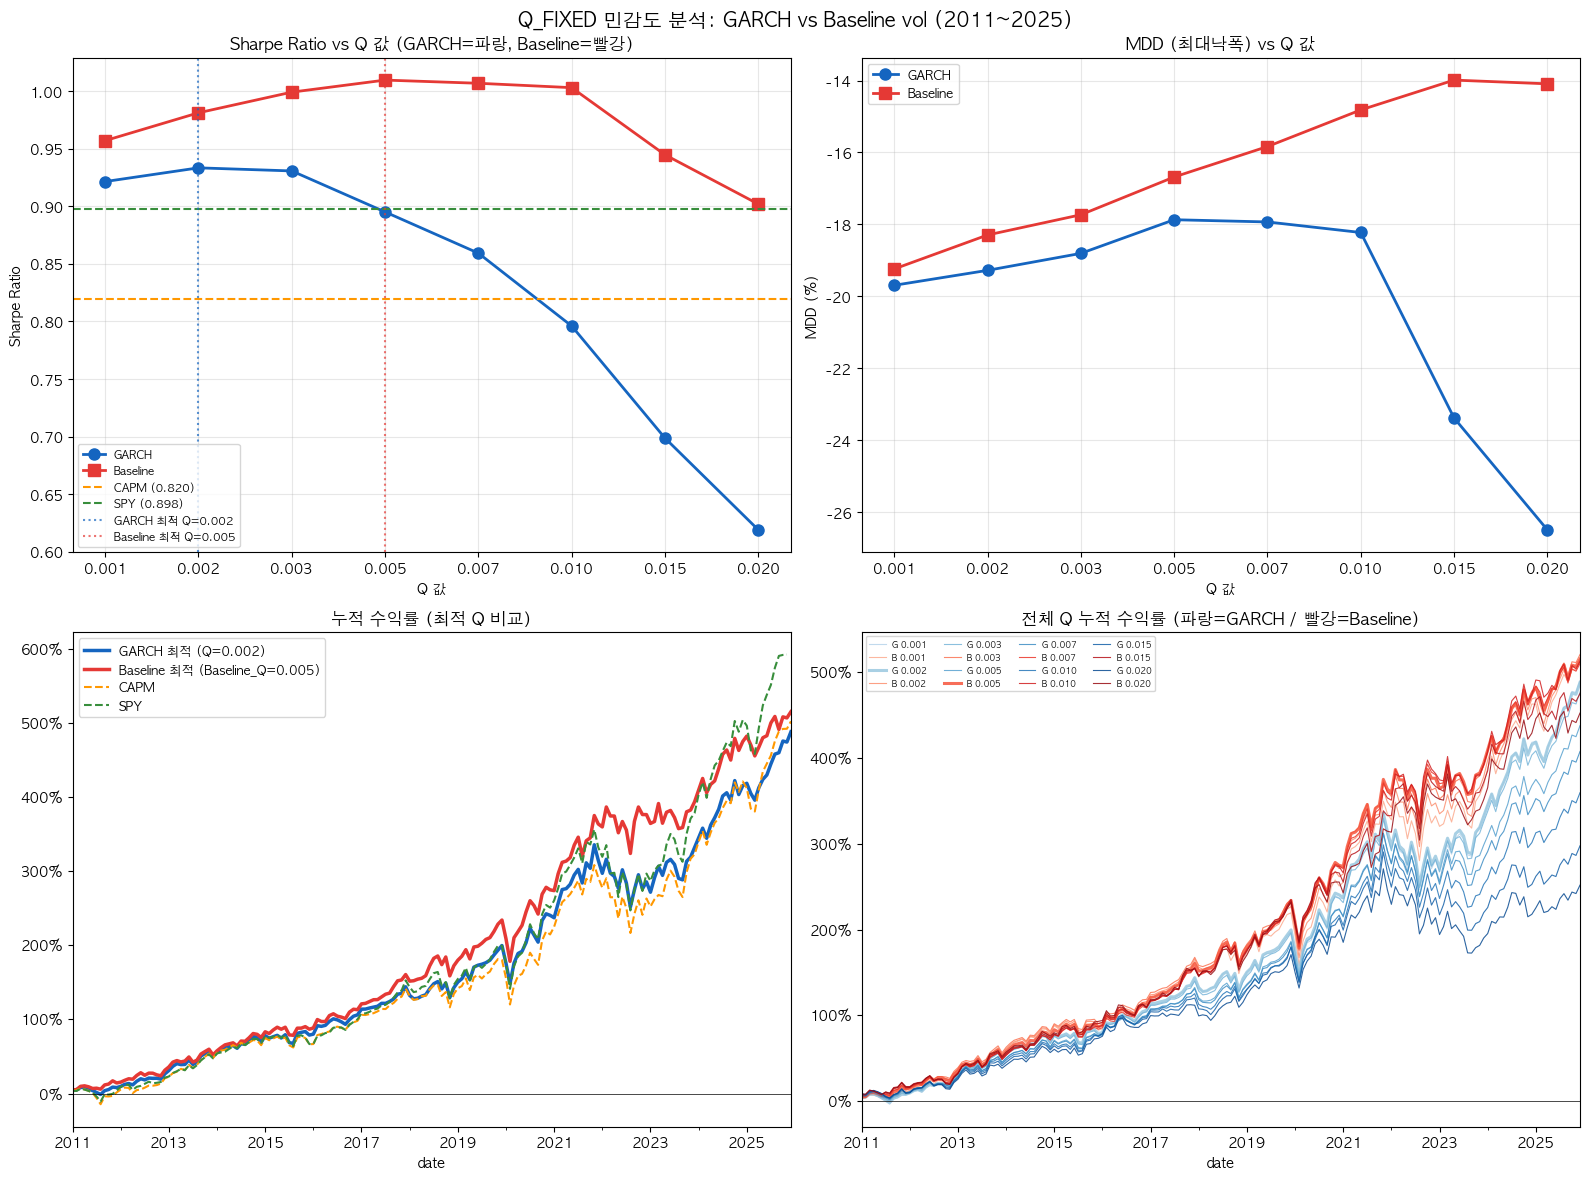


★ GARCH   최적 Q: 0.002    (Sharpe 0.934)
★ Baseline 최적 Q: 0.005    (Sharpe 1.010)


In [13]:
q_labels     = [f'{q:.3f}' for q in Q_CANDIDATES]
garch_sharpes = [garch_df.loc[f'Q={q:.3f}', 'sharpe'] for q in Q_CANDIDATES]
garch_mdds    = [garch_df.loc[f'Q={q:.3f}', 'mdd']    for q in Q_CANDIDATES]
bl_sharpes    = [bl_df.loc[f'Baseline_Q={q:.3f}', 'sharpe'] for q in Q_CANDIDATES]
bl_mdds       = [bl_df.loc[f'Baseline_Q={q:.3f}', 'mdd']    for q in Q_CANDIDATES]

capm_sharpe = garch_df.loc['CAPM', 'sharpe']
spy_sharpe  = garch_df.loc['SPY',  'sharpe']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Q_FIXED 민감도 분석: GARCH vs Baseline vol (2011~2025)', fontsize=14, fontweight='bold')

# ① Sharpe vs Q (GARCH & Baseline 비교)
ax = axes[0, 0]
ax.plot(q_labels, garch_sharpes, 'o-', color='#1565C0', linewidth=2, markersize=8, label='GARCH')
ax.plot(q_labels, bl_sharpes,   's-', color='#E53935', linewidth=2, markersize=8, label='Baseline')
ax.axhline(capm_sharpe, color='#FF9800', linestyle='--', linewidth=1.5, label=f'CAPM ({capm_sharpe:.3f})')
ax.axhline(spy_sharpe,  color='#388E3C', linestyle='--', linewidth=1.5, label=f'SPY ({spy_sharpe:.3f})')
best_g = garch_sharpes.index(max(garch_sharpes))
best_b = bl_sharpes.index(max(bl_sharpes))
ax.axvline(best_g, color='#1565C0', linestyle=':', linewidth=1.5, alpha=0.7, label=f'GARCH 최적 Q={Q_OPTIMAL_GARCH:.3f}')
ax.axvline(best_b, color='#E53935', linestyle=':', linewidth=1.5, alpha=0.7, label=f'Baseline 최적 Q={Q_OPTIMAL_BASELINE:.3f}')
ax.set_title('Sharpe Ratio vs Q 값 (GARCH=파랑, Baseline=빨강)')
ax.set_xlabel('Q 값')
ax.set_ylabel('Sharpe Ratio')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ② MDD vs Q
ax = axes[0, 1]
ax.plot(q_labels, [m * 100 for m in garch_mdds], 'o-', color='#1565C0', linewidth=2, markersize=8, label='GARCH')
ax.plot(q_labels, [m * 100 for m in bl_mdds],    's-', color='#E53935', linewidth=2, markersize=8, label='Baseline')
ax.set_title('MDD (최대낙폭) vs Q 값')
ax.set_xlabel('Q 값')
ax.set_ylabel('MDD (%)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ③ 최적 Q 누적 수익률 비교
ax = axes[1, 0]
opt_g_key = f'Q={Q_OPTIMAL_GARCH:.3f}'
opt_b_key = f'Baseline_Q={Q_OPTIMAL_BASELINE:.3f}'
(1 + ret_series[opt_g_key]).cumprod().subtract(1).plot(
    ax=ax, label=f'GARCH 최적 ({opt_g_key})', color='#1565C0', linewidth=2.5)
(1 + baseline_ret_series[opt_b_key]).cumprod().subtract(1).plot(
    ax=ax, label=f'Baseline 최적 ({opt_b_key})', color='#E53935', linewidth=2.5)
(1 + ret_series['CAPM']).cumprod().subtract(1).plot(
    ax=ax, label='CAPM', color='#FF9800', linestyle='--', linewidth=1.5)
(1 + ret_series['SPY']).cumprod().subtract(1).plot(
    ax=ax, label='SPY',  color='#388E3C', linestyle='--', linewidth=1.5)
ax.set_title('누적 수익률 (최적 Q 비교)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=9)
ax.axhline(0, color='black', linewidth=0.5)

# ④ 전체 Q 누적 수익률 (GARCH=파란 계열, Baseline=빨간 계열)
ax = axes[1, 1]
blues = plt.cm.Blues(np.linspace(0.3, 0.9, len(Q_CANDIDATES)))
reds  = plt.cm.Reds(np.linspace(0.3, 0.9, len(Q_CANDIDATES)))
for j, q_val in enumerate(Q_CANDIDATES):
    lw_g = 2.2 if q_val == Q_OPTIMAL_GARCH   else 0.8
    lw_b = 2.2 if q_val == Q_OPTIMAL_BASELINE else 0.8
    (1 + ret_series[f'Q={q_val:.3f}']).cumprod().subtract(1).plot(
        ax=ax, label=f'G {q_val:.3f}', color=blues[j], linewidth=lw_g, alpha=0.85)
    (1 + baseline_ret_series[f'Baseline_Q={q_val:.3f}']).cumprod().subtract(1).plot(
        ax=ax, label=f'B {q_val:.3f}', color=reds[j], linewidth=lw_b, alpha=0.85)
ax.set_title('전체 Q 누적 수익률 (파랑=GARCH / 빨강=Baseline)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=6, ncol=4)
ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig(OUT_DIR / 'q_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n★ GARCH   최적 Q: {Q_OPTIMAL_GARCH:.3f}    (Sharpe {SHARPE_GARCH_OPT:.3f})')
print(f'★ Baseline 최적 Q: {Q_OPTIMAL_BASELINE:.3f}    (Sharpe {SHARPE_BASELINE_OPT:.3f})')

# 최적 Q → 다음 단계 파이프라인

## GARCH 최적 Q → 08_Regime_Q_Portfolio

```python
# 08이 자동 로드 (GARCH only, 하위 호환)
STATS_05 = BASE_DIR / 'outputs' / '05_Q_Sensitivity' / 'q_sensitivity_stats.csv'
_s = pd.read_csv(STATS_05, index_col='label')
_bl = _s.drop(index=['CAPM', 'SPY'], errors='ignore')
Q_OPTIMAL = float(_bl['sharpe'].idxmax().split('=')[1])  # → GARCH 최적 Q
```

## Baseline 최적 Q → 06_BL_Q_Comparison (Q_FIXED 기반값)

```python
# 06이 자동 로드
BL_STATS = BASE_DIR / 'outputs' / '05_Q_Sensitivity' / 'q_sensitivity_baseline_stats.csv'
_bs = pd.read_csv(BL_STATS, index_col='label')
Q_FIXED = float(_bs['sharpe'].idxmax().split('=')[1])  # → Baseline 최적 Q
```

## BL 공식에서 Q의 역할

$$\mu_{BL} = \pi + \tau\Sigma P^T \left( P\tau\Sigma P^T + \Omega \right)^{-1} (Q - P\pi)$$

**Q가 제어하는 것**: `diff = Q - Pπ`
- `Pπ` = 현재 CAPM 균형에서 P 포트폴리오의 기대수익률
- `Q - Pπ` = BL이 μ를 π에서 얼마나 밀어낼지의 크기
- Q가 클수록 저위험 종목에 더 강한 over-weight 신호

## 해석 원칙

| Q 값 | BL 조정 강도 | 포트폴리오 성격 |
|------|-------------|----------------|
| 작음 (0.001~0.003) | 약함 → CAPM에 가까움 | 분산 유지, 낮은 MDD |
| 중간 (0.005~0.007) | 중간 | 저위험 tilting 명확 |
| 큰 값 (0.015~0.020) | 강함 → 저위험 집중 | 변동성↑, MDD↑ |